<a href="https://colab.research.google.com/github/Kseniaa31/Data-Science/blob/Airline-Tickets/Airline_Tickets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

# **DATA READING**

In [ ]:
train_data= pd.read_excel("Data_Train.xlsx")
train_data.head(4) #only 4 first rows will be displayed
train_data.tail(4) #only 4 last rows will be displayed

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


# **DATA CLEANING AND PREPROCESSING**

In [ ]:
train_data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [ ]:
train_data[train_data['Total_Stops'].isnull()]
train_data.dropna(inplace=True) #dropna removes the rows with missing values (we can drop them because we have very few cases)
train_data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [ ]:
train_data.dtypes
train_data.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 6.3 MB


In [ ]:
data=train_data.copy()
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [ ]:
def change_into_DateTime(col):
  data[col]=pd.to_datetime(data[col])

In [ ]:
data.columns
for feature in ['Dep_Time', 'Arrival_Time', 'Date_of_Journey']:
  change_into_DateTime(feature)
data.dtypes

,0
Airline,object
Date_of_Journey,datetime64[ns]
Source,object
Destination,object
Route,object
Dep_Time,datetime64[ns]
Arrival_Time,datetime64[ns]
Duration,object
Total_Stops,object
Additional_Info,object


In [ ]:
data["Journey_day"]=data['Date_of_Journey'].dt.day #extracts day, month and year of the journey
data["Journey_month"]=data['Date_of_Journey'].dt.month
data["Journey_year"]=data['Date_of_Journey'].dt.year
data.head(4)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-09-13 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-09-13 05:50:00,2025-09-13 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-09-13 09:25:00,2025-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2025-09-13 18:05:00,2025-09-13 23:30:00,5h 25m,1 stop,No info,6218,12,5,2019


In [ ]:
def extract_hour_min(df,col):
  df[col+"_hour"]=df[col].dt.hour
  df[col+"_minute"]=df[col].dt.minute
  return df.head(3)

In [ ]:
extract_hour_min(data, "Dep_Time")
extract_hour_min(data, "Arrival_Time")

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-09-13 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-09-13 05:50:00,2025-09-13 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-09-13 09:25:00,2025-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [ ]:
cols_to_drop= ["Arrival_Time", "Dep_Time"]
data.drop(cols_to_drop, axis=1, inplace=True)
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [ ]:
data.shape

(10682, 16)

# **DATA ANALYSIS**

In [ ]:
def flight_dep_time(x):
  if (x>4) and (x<=8):
    return "Early morning"
  elif (x>8) and (x<=12):
    return "Morning"
  elif (x>12) and (x<=16):
    return "Afternoon"
  elif (x>16) and (x<=20):
    return "Evening"
  elif (x>20) and (x<=24):
    return "Night"
  else:
    return "Late night"

<Axes: xlabel='Dep_Time_hour'>

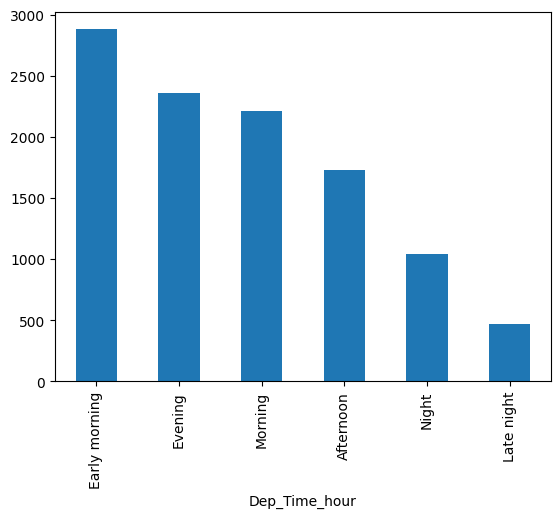

In [ ]:
data['Dep_Time_hour'].apply(flight_dep_time).value_counts().plot(kind="bar")

In [ ]:
!pip install plotly
!pip install chart_studio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00


In [ ]:
import plotly
import cufflinks as cf
from cufflinks.offline import go_offline
from plotly.offline import plot, iplot, init_notebook_mode, download_plotlyjs
init_notebook_mode(connected=True)
cf.go_offline()

In [ ]:
def preprocess_duration(x):
  if 'h' not in x:
    x= '0h' + ' ' + x
  elif 'm' not in x:
    x= x+ ' ' + '0m'
  return x

In [ ]:
data['Duration']=data['Duration'].apply(preprocess_duration)
data['Duration']

,Duration
0,2h 50m
1,7h 25m
2,19h 0m
3,5h 25m
4,4h 45m
...,...
10678,2h 30m
10679,2h 35m
10680,3h 0m
10681,2h 40m


In [ ]:
data['Duration_hours']=data['Duration'].apply(lambda x: int(x.split(' ')[0][0:-1]))
data['Duration_mins']=data['Duration'].apply(lambda x: int(x.split(' ')[1][0:-1]))


In [ ]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,6,2019,9,25,4,25,19,0


In [ ]:
data['Duration_total_mins']=data['Duration'].str.replace("h", "*60").str.replace(" ", "+").str.replace("m", "*1").apply(eval)
data['Duration_total_mins']

,Duration_total_mins
0,170
1,445
2,1140
3,325
4,285
...,...
10678,150
10679,155
10680,180
10681,160


<Axes: xlabel='Duration_total_mins', ylabel='Price'>

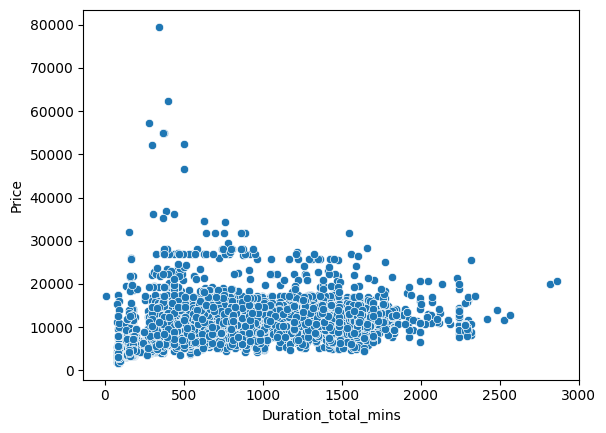

In [ ]:
sns.scatterplot(x="Duration_total_mins", y="Price", data=data)
#scatterplot including only duration and price

<Axes: xlabel='Duration_total_mins', ylabel='Price'>

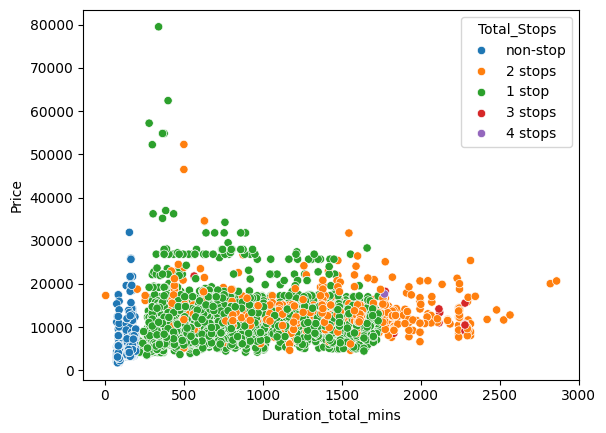

In [ ]:
sns.scatterplot(x="Duration_total_mins", y="Price",hue="Total_Stops", data=data)
#scatterplot including also number of total stops and how they affect the price

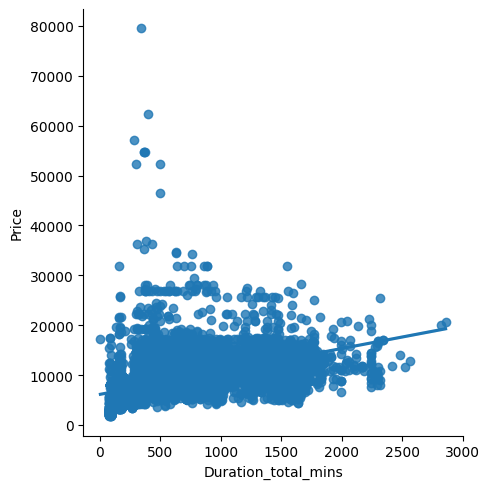

In [ ]:
sns.lmplot(x="Duration_total_mins", y="Price", data=data)
#regression plot showing that if duration increases, so does the price

In [ ]:
#Check for which routes the airline Jet Airways is mostly used
data[data['Airline']=="Jet Airways"].groupby('Route').size().sort_values(ascending=False)

,0
Route,
CCU → BOM → BLR,930
DEL → BOM → COK,875
BLR → BOM → DEL,385
BLR → DEL,382
CCU → DEL → BLR,300
DEL → JAI → BOM → COK,207
BOM → HYD,207
DEL → AMD → BOM → COK,141
DEL → IDR → BOM → COK,86


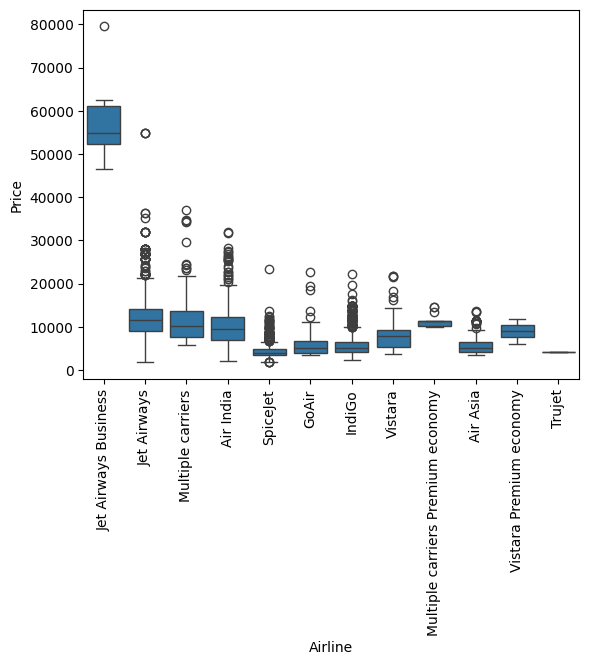

In [ ]:
#Airline vs Price analysis
sns.boxplot(y="Price", x="Airline", data=data.sort_values("Price",ascending=False))
plt.xticks(rotation="vertical")
plt.show()

# **FEATURE ENGINEERING**

**ONE-HOT ENCODING**

In [ ]:
#Feature encoding --> Converting categorical data into numerical data in order to be used in a ML model
#One-hot-encoding --> Used for nominal data
#Label-encoding -> Used for ordinal data
cat_col=[col for col in data.columns if data[col].dtype=="object"]
num_col=[col for col in data.columns if data[col].dtype!="object"]

In [ ]:
data['Source'].unique()
data['Source'].apply(lambda x : 1 if x=="Banglore" else 0)
#One hot encoding for the feature "Banglore"

,Source
0,1
1,0
2,0
3,0
4,1
...,...
10678,0
10679,0
10680,1
10681,1


In [ ]:
for sub_category in data['Source'].unique():
  data['Source_'+sub_category]=data['Source'].apply(lambda x: 1 if x==sub_category else 0)
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


In [ ]:
data['Airline'].nunique()
#Need to use optimized feature encoding because we would have a high dimensionality
airlines=data.groupby(['Airline'])['Price'].mean().sort_values().index
airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='object', name='Airline')

In [ ]:
dict_airlines= {key:index for index, key in enumerate(airlines,0)}
dict_airlines
data['Airline']=data['Airline'].map(dict_airlines)
data['Airline']

,Airline
0,3
1,7
2,10
3,3
4,3
...,...
10678,2
10679,7
10680,10
10681,5


In [ ]:
data['Destination'].replace('New Delhi', 'Delhi', inplace=True) #same data with different names
data['Destination'].unique()

array(['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad'],
      dtype=object)

In [ ]:
dest= data.groupby(['Destination'])['Price'].mean().sort_values().index
dict_dest={key:index for index,key in enumerate(dest,0)}
data['Destination']=data['Destination'].map(dict_dest)
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


**LABEL ENCODING**

In [ ]:
data['Total_Stops'].unique() #ordinal data --> Label encoding
stop={'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}
data['Total_Stops']=data['Total_Stops'].map(stop)
data['Total_Stops']

,Total_Stops
0,0
1,2
2,2
3,1
4,1
...,...
10678,0
10679,0
10680,0
10681,0


In [ ]:
data['Additional_Info'].value_counts()/len(data)*100 #Most of the rows (78 %) have no info so we can remove

,count
Additional_Info,
No info,78.112713
In-flight meal not included,18.554578
No check-in baggage included,2.995694
1 Long layover,0.177869
Change airports,0.065531
Business class,0.037446
No Info,0.028085
1 Short layover,0.009362
Red-eye flight,0.009362


In [ ]:
data.drop(columns=['Date_of_Journey', 'Additional_Info', 'Duration_total_mins', 'Source', 'Journey_year', 'Route', 'Duration'], axis=1, inplace=True)
#We can drop those columns because they contain no new information --> redundant
data.head(3)

,Airline,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0
2,10,4,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0


**OUTLIERS DETECTION AND HANDLING**

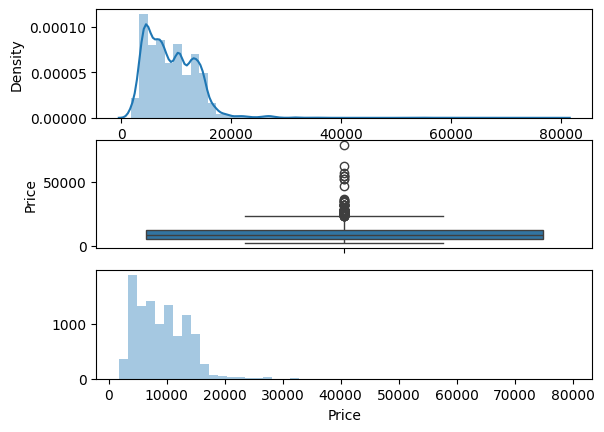

In [ ]:
#Box plot -> Used to detect outliers (numerical data)
def plot(df, col):
  fig , (ax1,ax2,ax3)= plt.subplots(3,1)
  sns.distplot(df[col],ax=ax1)
  sns.boxplot(df[col],ax=ax2)
  sns.distplot(df[col],ax=ax3, kde=False)
plot(data, 'Price')

In [ ]:
q1= data['Price'].quantile(0.25)
q3=data['Price'].quantile(0.75)
iqr = q3 - q1
maximum = q3 + 1.5*iqr
minimum = q1 - 1.5*iqr
print(maximum, minimum)

23017.0 -5367.0


In [ ]:
len([price for price in data['Price'] if price> maximum or price < minimum]) #number of outliers

94

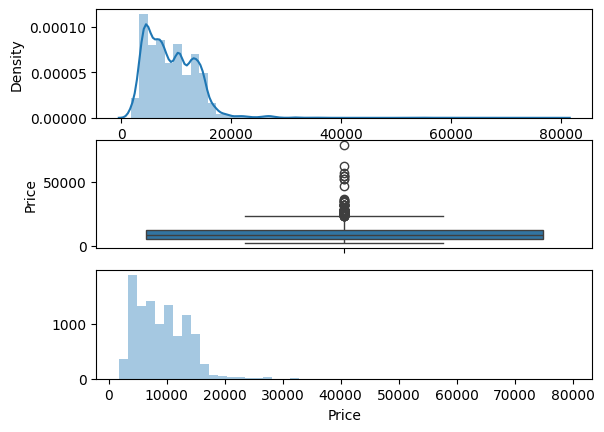

In [ ]:
#replace the outliers with the median value because it is not affected by the outliers (middle value)
#mean is badly affected by outliers --> that is why we do not replace with mean
np.where(data['Price']>=25000, data['Price'].median(),data['Price'])
plot(data,'Price')

**FEATURE SELECTION --> Independent and Dependent Features**

In [ ]:
#Mutual Information (MI) Approach --> Returns whether 2 random variables (features are dependent or not)
#If MI=0 --> Independent, otherwise --> Dependent
X= data.drop(['Price'], axis=1)
y= data['Price']
from sklearn.feature_selection import mutual_info_regression
imp= mutual_info_regression(X,y)
imp_df=pd.DataFrame(imp, index=X.columns)
imp_df.columns=['Importance']
imp_df

,Importance
Airline,1.320777
Destination,1.058076
Total_Stops,0.798475
Journey_day,0.369575
Journey_month,0.626268
Dep_Time_hour,0.930880
Dep_Time_minute,0.763942
Arrival_Time_hour,1.138496
Arrival_Time_minute,0.898393
Duration_hours,1.121276


In [ ]:
imp_df.sort_values(by='Importance', ascending=False)
#If we have a lot of data, we could drop the features with lowest importance
#This case --> Very few features, so we do not drop

,Importance
Airline,1.320777
Arrival_Time_hour,1.138496
Duration_hours,1.121276
Destination,1.058076
Dep_Time_hour,0.930880
Arrival_Time_minute,0.898393
Total_Stops,0.798475
Dep_Time_minute,0.763942
Duration_mins,0.677943
Journey_month,0.626268


# **ML MODEL BUILDING**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.25, random_state=42)
ml_model=RandomForestRegressor()
ml_model.fit(X_train, y_train)
y_pred=ml_model.predict(X_test)
y_pred
metrics.r2_score(y_test, y_pred)

0.800609425405957

In [ ]:
!pip install pickle

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [ ]:
import pickle
file= open(r'rf_random.pkl','wb')
pickle.dump(ml_model, file)
model=open(r'rf_random.pkl', 'rb')
forest=pickle.load(model)
y_pred2=forest.predict(X_test)
metrics.r2_score(y_test, y_pred2)

0.800609425405957

**EVALUATION METRICS**

In [ ]:
def mape(y_true, y_pred): #mean absolute percentage error
  y_true, y_pred=np.array(y_true), np.array(y_pred)
  return np.mean(np.abs((y_true - y_pred)/ y_true))*100
mape(y_test, y_pred)

np.float64(13.189824410363233)

Training score : 0.9535189215196515
Predictions are : [16879.9   5386.66  8832.16 ...  3504.2   6086.    6782.55]
r2 score : 0.8016442320249617
MAE : 1171.966555341888
MSE : 4088712.685546615
RMSE : 2022.0565485531347
MAPE : 13.048385454111767


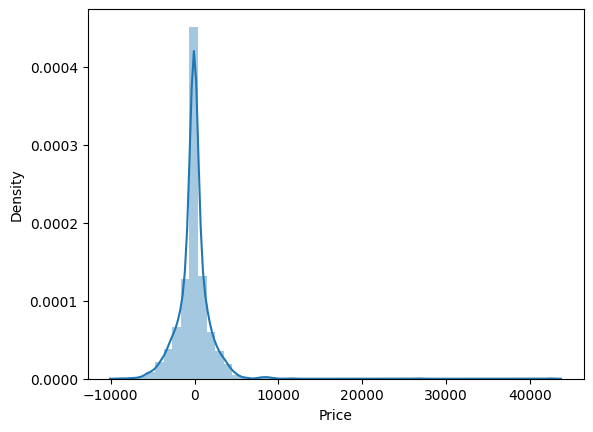

In [ ]:
def predict(ml_model):
  model=ml_model.fit(X_train, y_train)
  print('Training score : {}'.format(model.score(X_train, y_train)))
  y_prediction=model.predict(X_test)
  print('Predictions are : {}'.format(y_prediction))
  r2_score= metrics.r2_score(y_test, y_prediction)
  print('r2 score : {}'.format(r2_score))
  print('MAE : {}'.format(metrics.mean_absolute_error(y_test, y_prediction)))
  print('MSE : {}'.format(metrics.mean_squared_error(y_test, y_prediction)))
  print('RMSE : {}'.format(np.sqrt(metrics.mean_squared_error(y_test, y_prediction))))
  print('MAPE : {}'.format(mape(y_test, y_prediction)))
  sns.distplot(y_test - y_prediction)

predict(RandomForestRegressor())

Training score : 0.9707490055980877
Predictions are : [16840.  4959.  8085. ...  3419.  5797.  6442.]
r2 score : 0.694166137699419
MAE : 1387.808373892425
MSE : 6304161.48329735
RMSE : 2510.808930065637
MAPE : 15.370060118360183


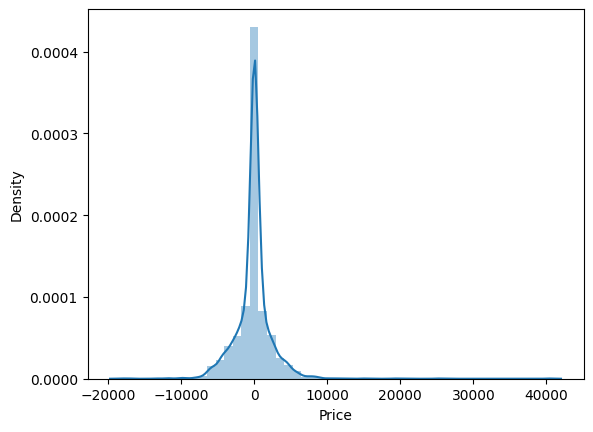

In [ ]:
from sklearn.tree import DecisionTreeRegressor
predict(DecisionTreeRegressor())

**HYPERTUNING A ML MODEL**

In [ ]:
#Hypertune is the same as optimizing a hyper-parameter
from sklearn.model_selection import RandomizedSearchCV
reg_rf = RandomForestRegressor()

#specifying Random Forest parameters:
n_estimators=[int(x) for x in np.linspace(start=100, stop=1200, num=6)]
max_features= ["auto", "sqrt"]
max_depth= [int(x) for x in np.linspace(start=5, stop=30, num=4)]
min_samples_split=[5,10,15,100]

random_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split
}
random_grid

{'n_estimators': [100, 320, 540, 760, 980, 1200],
 'max_features': ['auto', 'sqrt'],
 'max_depth': [5, 13, 21, 30],
 'min_samples_split': [5, 10, 15, 100]}

In [ ]:
rf_random = RandomizedSearchCV(estimator=reg_rf, param_distributions=random_grid, cv=3, n_jobs=-1, verbose=2)
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 13, 21, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_split': [5, 10, 15, 100],
                                        'n_estimators': [100, 320, 540, 760,
                                                         980, 1200]},
                   verbose=2)

In [ ]:
rf_random.best_params_

{'n_estimators': 1200,
 'min_samples_split': 5,
 'max_features': 'sqrt',
 'max_depth': 13}

In [ ]:
rf_random.best_estimator_

RandomForestRegressor(max_depth=13, max_features='sqrt', min_samples_split=5,
                      n_estimators=1200)

In [ ]:
rf_random.best_score_

np.float64(0.796877268150349)